<a href="https://colab.research.google.com/github/ghn9zh/DS3001-programming/blob/main/WranglingLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wrangling Lab

Gwen Thompson

ghn9zh

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import requests # Page requests

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} # How we wish to appear to CL
url = 'https://charlottesville.craigslist.org/search/jwa#search=1~gallery~0~0' # The page we want to scrape
raw = requests.get(url,headers=header) # Get page

In [ ]:
from bs4 import BeautifulSoup as soup # HTML parser
bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings of the kind we want

In [ ]:
import re # Regular expressions

categories = ['ring', 'box','bracelet','watch','pin','sunglasses','necklace','earring']

data = [] # We'll save our listings in this object
for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()

    location_element = listings[k].find('div', class_='location')
    location = location_element.get_text() if location_element else ''

    price = listings[k].find('div',class_='price').get_text()

    link = listings[k].find(href=True)['href']
    # Get category from the title string:
    words = title.split()
    hits = [word for word in words if word in categories] # Find category of jewelery in the title
    if len(hits) == 0:
        category = 'missing'
    else:
        category = hits[0]
    #
    data.append({'title':title,'price':price,'link':link,'category':category, 'location':location})

In [ ]:
import os
## Wrangle the data
df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
print(df.shape)
os.makedirs('src', exist_ok=True)
df.to_csv('./src/craigslist_cville_jewelery.csv') # Save data in case of a disaster
df.head()

(20, 5)


,title,price,link,category,location
0,"> ladies ring - amethyst, diamonds & 10k gold,...",0,https://charlottesville.craigslist.org/jwl/d/c...,ring,\n Charlottesville\n ...
1,new jeweled heart trinket box with hanger,35,https://charlottesville.craigslist.org/jwl/d/e...,box,\n Earlysville\n ...
2,reed and barton damascene choker and bracelet,40,https://charlottesville.craigslist.org/jwl/d/e...,bracelet,\n Earlysville\n ...
3,seiko watch,40,https://charlottesville.craigslist.org/jwl/d/s...,watch,\n Spotsylvania\n ...
4,vintage mother rhinestone enamel floral brooch...,20,https://charlottesville.craigslist.org/jwl/d/e...,pin,


In [ ]:
df.loc[:,['price','category']].groupby('category').describe()

price                                                          \
           count         mean          std    min     25%    50%     75%   
category                                                                   
box          3.0    18.333333    14.433757   10.0   10.00   10.0    22.5   
bracelet     2.0   220.000000   254.558441   40.0  130.00  220.0   310.0   
missing      5.0  2156.000000  4136.765645   10.0   20.00   50.0  1200.0   
necklace     2.0    70.000000    77.781746   15.0   42.50   70.0    97.5   
pin          1.0    20.000000          NaN   20.0   20.00   20.0    20.0   
ring         2.0   150.000000   212.132034    0.0   75.00  150.0   225.0   
sunglasses   1.0   200.000000          NaN  200.0  200.00  200.0   200.0   
watch        4.0   378.750000   549.520624   40.0  103.75  137.5   412.5   

                    
               max  
category            
box           35.0  
bracelet     400.0  
missing     9500.0  
necklace     125.0  
pin           20.0  
ring         300.0  
sunglasses   200.0  
watch       1200.0

In [ ]:
df.loc[:,['location','category']].groupby('category').describe()

location                                                            \
              count unique                                                top   
category                                                                        
box               3      2  \n                        Louisa\n            ...   
bracelet          2      2  \n                        Earlysville\n       ...   
missing           5      5  \n                        Charlottesville\n   ...   
necklace          2      2                                                      
pin               1      1                                                      
ring              2      2  \n                        Charlottesville\n   ...   
sunglasses        1      1  \n                        Ruckersville\n      ...   
watch             4      2  \n                        Nellysford\n        ...   

                 
           freq  
category         
box           2  
bracelet      1  
missing       1  
necklace      1  
pin           1  
ring          1  
sunglasses    1  
watch         3

In [ ]:
import altair as alt

# Count the occurrences of each category
filtered_df = df[df['category'] != 'missing']
category_counts = filtered_df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

# Create the bar chart
chart = alt.Chart(category_counts).mark_bar().encode(
    x='category:N',  # Nominal encoding for categories
    y='count:Q',  # Quantitative encoding for counts
    color='category:N' # Color each bar by category
).properties(
    title='Amount of Jewelry in Each Category',
    width=600,
    height=400
)

chart

alt.Chart(...)

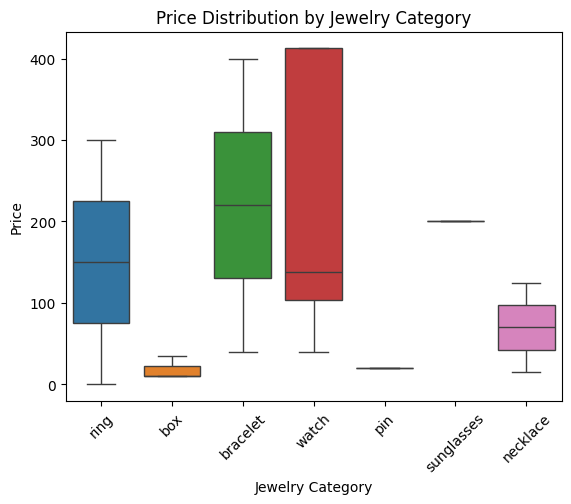

In [ ]:
filtered_df = df[df['category'] != 'missing']
sns.boxplot(x='category', y='price', hue = 'category', data=filtered_df, showfliers=False)
plt.title('Price Distribution by Jewelry Category')
plt.xlabel('Jewelry Category')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()